## 数据处理版本v2: 
### 2025-0907

对csv手动进行了一些处理：

AB_C
B_CD
手动修改【DADA_MN（重-轻）/ 4U6H_AB_E【A重链-B轻链】/3NPS_A_BC【B-重链-C轻链】】
都改成：前轻后重；
使用前轻后重； 单独的为抗原；
HL如果有，单独的为抗原。 数据标注完成

4NM8_ABCDEF_HL，保留B
5DWU_HL_AB，保留B链作为抗原，删除一条突变点再A上的样本数据。
4KRP_A_B其中B是纳米抗体，所以在tsv中修改为4KRP_A_CB，将B处理为重链，并且在seqs中补入C=“”

In [1]:

import tarfile
tar = tarfile.open(r"/root/private_data/luog/Data_AbAg/skempi/SKEMPI2_PDBs.tgz", 'r:gz')
name_list = [m.name for m in tar.getmembers()]
mapping_files = {name.split('/')[-1].split('.')[0]: name for name in name_list if name.endswith('.mapping')}  

In [4]:
import warnings
from Bio import PDB
import numpy as np
import json
from tqdm import tqdm
from Bio.Data.PDBData import protein_letters_3to1_extended 

def save_to_json(data, json_file):
    with open(json_file, 'w', encoding='utf-8') as jsonfile:
        json.dump(data, jsonfile, ensure_ascii=False, indent=None)


def read_mapping_file(file):
    extended_andUNK = protein_letters_3to1_extended
    extended_andUNK["UNK"] = "X"  # 如果为UNK则修改为X，最终修改掉突变之后删除前面的X
    file = file.split("\n")
    chains = {}
    for line in file:
        parts = line.split()
        if len(parts) == 0:
            continue
        if len(parts) == 3:
            parts = [parts[0], parts[1][0],parts[1][1:] ,parts[2]]
        
        if parts[1] not in chains.keys():
            chains[parts[1]] = extended_andUNK[parts[0]]
        else:
            chains[parts[1]] = chains[parts[1]] + extended_andUNK[parts[0]]
    return chains


result=[]
for k,v in tqdm(mapping_files.items()):
    try:
        f = tar.extractfile(v)
        content = f.read().decode('utf-8')
        seqs = read_mapping_file(content)
        f.close()
        result.append({"pdb":k,"seqs":seqs})
    except:
        print(k,v)
        continue
save_to_json(result,"/root/private_data/luog/Data_AbAg/skempi/result/skempi_seqsinfo.json")

  4%|▍         | 15/346 [00:00<00:15, 21.11it/s]

 PDBs/._5DWU.mapping


100%|██████████| 346/346 [00:01<00:00, 203.95it/s]


In [59]:
from Bio.Data.PDBData import protein_letters_3to1_extended 
import tarfile
import json
import os
import json
import random
import string
from tqdm import tqdm
import copy
import warnings
from Bio import PDB
import numpy as np
import json
from tqdm import tqdm

def save_to_json(data, json_file):
    with open(json_file, 'w', encoding='utf-8') as jsonfile:
        json.dump(data, jsonfile, ensure_ascii=False, indent=None)


def fix_col(i):
    # 如果给了突变信息，则修改序列，再做轻/重/抗原链赋值
    seqs = i["seqs"]
    if i["mutation"]!="wt_type":
        Mutation_Point = i["mutation"].split(",")
        for p in Mutation_Point:
            index = int(p[2:-1])-1
            seq = seqs[p[1]] # 获取原始序列
            if seq[index]==p[0]:
                seqs[p[1]] =  seq[:index] + p[-1] + seq[index+1:] # 赋值
                # print("修改序列")
            else:
                print(i["pdb"],p,seq[index-1],p[0],"修改失败")

    chains_info = i["pdb"].split("_",1)[1]
    if ("HL" in chains_info) or ("LH" in chains_info):
        chains_other = chains_info.replace("_","").replace("HL","").replace("LH","")
        i["X"] = seqs[chains_other]
        i["P"] = ""
        i["H"] = seqs["H"]
        i["L"] = seqs["L"]
        i["seqs"] = chains_other+"HL"
    else:
        chains_info = chains_info.split("_")
        for j in chains_info:
            if len(j) == 2:
                # 前轻后重
                i["L"] = seqs[j[0]]
                i["H"] = seqs[j[1]]
            else:
                i["X"] = seqs[j]

        i["seqs"] = "XXX"
    return i

def generate_id(length=5):
    return ''.join(random.choices(string.ascii_uppercase, k=length))

def skermpi(csv_data,save_dir):
    with open("/root/private_data/luog/Data_AbAg/skempi/result/skempi_seqsinfo.json", 'r', encoding='utf-8') as f:
        data_seqs = json.load(f)
        seqs_dict={}
        for i in data_seqs:
            seqs_dict[i["pdb"]]=i["seqs"]
        
    data_wt=[] 
    data_mt=[] 
    pdb_set=[]


    with open(csv_data, 'r', encoding='utf-8') as f:
        data = f.readlines() 
        for i in tqdm(data[1:]):
            data_i = i.strip().split(";")
            pdb_name = data_i[0].split("_")[0].upper()
        # try:
            if "AB/AG" in data_i[4]:
                # 突变型放入数据
                col_mt = fix_col({
                        "pdb":data_i[0],
                        "seqs": copy.deepcopy(seqs_dict[pdb_name]),
                        "mutation":data_i[2],
                        "kd":-np.log10(float(data_i[7])) if data_i[7]!="" else 0.0,
                        "kon":-np.log10(float(data_i[15])) if data_i[15]!="" else 0.0,
                        "koff":-np.log10(float(data_i[19])) if data_i[19]!="" else 0.0,
                        "Hold_out_type":data_i[4],
                    })
                col_mt["pdb"] = pdb_name+"_"+generate_id(5)
                data_mt.append(col_mt)
                # 野生型放入数据
                if pdb_name not in pdb_set:
                    pdb_set.append(pdb_name) 
                    col_wt = fix_col({
                        "pdb":data_i[0],
                        "seqs": copy.deepcopy(seqs_dict[pdb_name]),
                        "mutation":"wt_type",
                        "kd":-np.log10(float(data_i[9])) if data_i[9]!="" else 0.0,
                        "kon":-np.log10(float(data_i[17])) if data_i[17]!="" else 0.0,
                        "koff":-np.log10(float(data_i[21])) if data_i[21]!="" else 0.0,
                        "Hold_out_type":data_i[4],
                    })
                    col_wt["pdb"] = pdb_name+"_"+generate_id(5)
                    data_wt.append(col_wt)

                # print("data_wt",data_wt)
                # print("data_mt",data_mt)
                # break
        # except:
        #     # print(i)
        #     continue

            
    data_all = data_wt + data_mt

    save_to_json(data_all,os.path.join(save_dir,"skempi_AbAg_"+str(len(data_all))+".json"))
    data_koff = []
    for i in data_all:
        if i["koff"] > 0.0:
            data_koff.append(i)
    save_to_json(data_koff,os.path.join(save_dir,"skempi_AbAgAoff_"+str(len(data_koff))+".json"))
    return data_all

random.seed(42)
csv_data="/root/private_data/luog/Data_AbAg/skempi/skempi_v2_change.csv"
save_dir="/root/private_data/luog/Data_AbAg/skempi/result"
data_all = skermpi(csv_data,save_dir)
print("一共",len(data_all),"条数据")


100%|██████████| 7037/7037 [00:00<00:00, 7775.12it/s] 

一共 1217 条数据


## 清洗数据发现skempi中存在大量重复的数据集项目，例如同一个pdb+突变位点被记录多个；
所以去重，要求以保留koff项目为主； 可以考虑假装没有重复项，然后做实验。

### 可视化


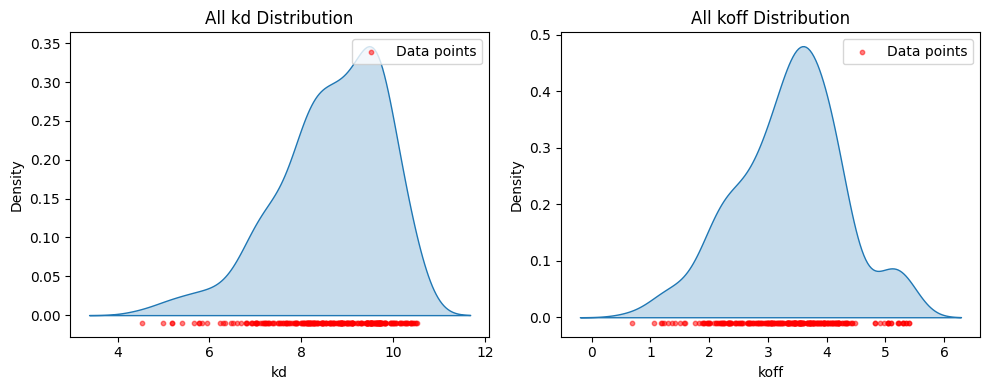

/tmp/ipykernel_13018/1232607561.py:55: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(values, fill=True, ax=ax)


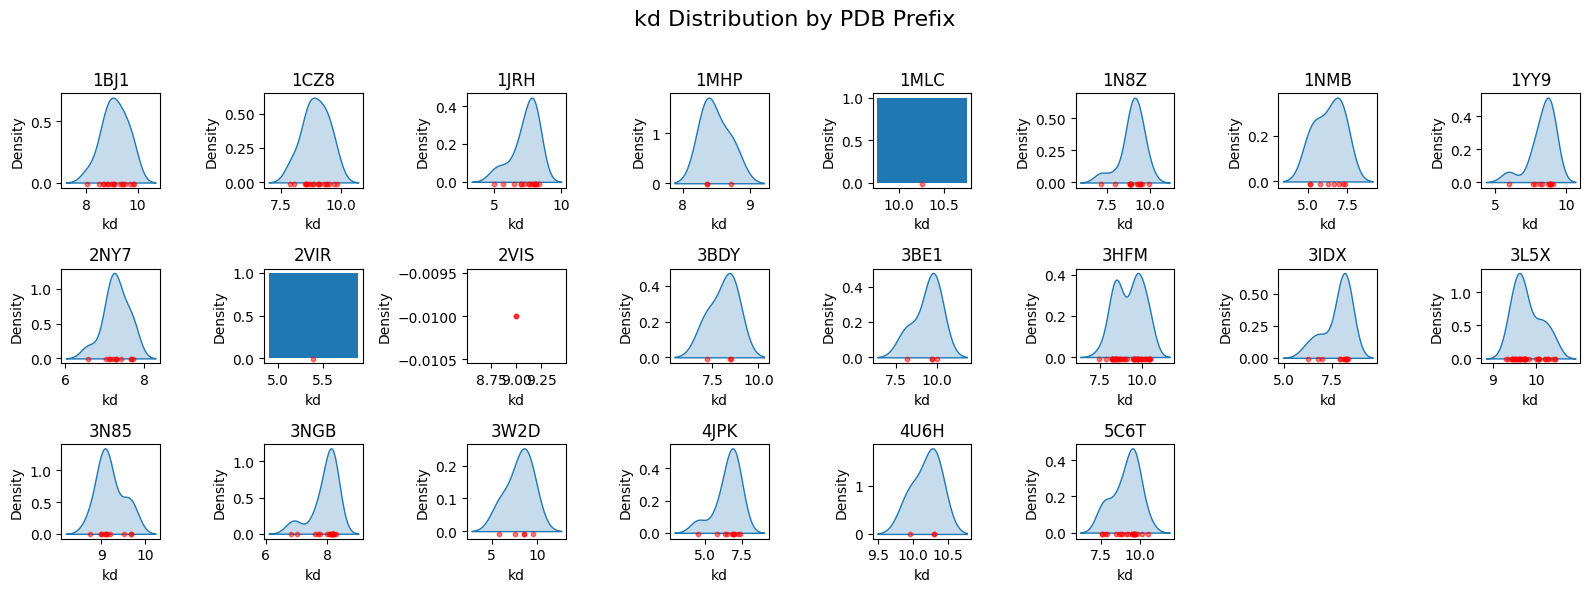

/tmp/ipykernel_13018/1232607561.py:75: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(values, fill=True, ax=ax)


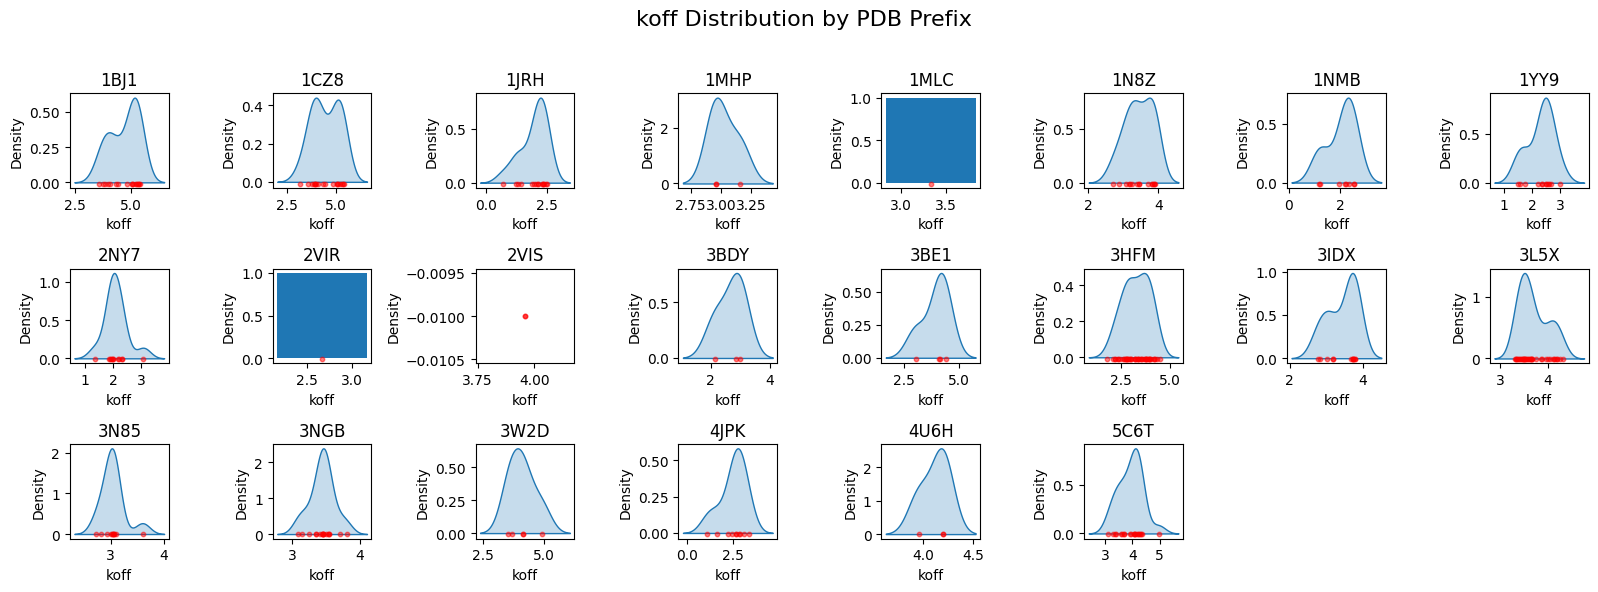

In [54]:

import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import math

# 读取数据
input_file = r"/root/private_data/luog/Data_AbAg/skempi/result/skempi_AbAgAoff_272.json"
with open(input_file, "r") as f:
    data = json.load(f)

# 1. 整体分布可视化（kd/koff）
kd_all = [float(entry["kd"]) for entry in data]
koff_all = [float(entry["koff"]) for entry in data]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(kd_all, fill=True)
plt.scatter(kd_all, [-0.01]*len(kd_all), color='red', alpha=0.5, s=10, label='Data points')
plt.title('All kd Distribution')
plt.xlabel('kd')
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(koff_all, fill=True)
plt.scatter(koff_all, [-0.01]*len(koff_all), color='red', alpha=0.5, s=10, label='Data points')
plt.title('All koff Distribution')
plt.xlabel('koff')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# 2. 按PDB前四字母分组可视化
# 分组
grouped = defaultdict(lambda: {"kd": [], "koff": []})
for entry in data:
    pdb_prefix = entry["pdb"][:4]
    grouped[pdb_prefix]["kd"].append(float(entry["kd"]))
    grouped[pdb_prefix]["koff"].append(float(entry["koff"]))

group_keys = sorted(grouped.keys())
num_groups = len(group_keys)
cols = 8
rows = math.ceil(num_groups / cols)

# 绘制kd分布
fig_kd, axes_kd = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes_kd = axes_kd.flatten()
for i, pdb_prefix in enumerate(group_keys):
    ax = axes_kd[i]
    values = grouped[pdb_prefix]["kd"]
    if len(values) > 1:
        sns.kdeplot(values, fill=True, ax=ax)
    else:
        ax.hist(values, bins=1)
    ax.scatter(values, [-0.01]*len(values), color='red', alpha=0.5, s=10)
    ax.set_title(pdb_prefix)
    ax.set_xlabel('kd')
    ax.set_ylabel('Density')
for j in range(i+1, len(axes_kd)):
    fig_kd.delaxes(axes_kd[j])
fig_kd.suptitle('kd Distribution by PDB Prefix', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 绘制koff分布
fig_koff, axes_koff = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes_koff = axes_koff.flatten()
for i, pdb_prefix in enumerate(group_keys):
    ax = axes_koff[i]
    values = grouped[pdb_prefix]["koff"]
    if len(values) > 1:
        sns.kdeplot(values, fill=True, ax=ax)
    else:
        ax.hist(values, bins=1)
    ax.scatter(values, [-0.01]*len(values), color='red', alpha=0.5, s=10)
    ax.set_title(pdb_prefix)
    ax.set_xlabel('koff')
    ax.set_ylabel('Density')
for j in range(i+1, len(axes_koff)):
    fig_koff.delaxes(axes_koff[j])
fig_koff.suptitle('koff Distribution by PDB Prefix', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
# ... existing code ...

# 下面都是关于这个数据集的按结构切分过程

In [1]:
import json
from collections import Counter

# 文件路径
file_path = "./skempi_AbAg_Kall272.json"

# 读取json文件
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# 统计pdb前四个字符
pdb_counter = Counter()
for entry in data:
    pdb_name = entry.get("pdb", "")
    if len(pdb_name) >= 4:
        pdb_counter[pdb_name[:4]] += 1

# 按数量排序并输出
for pdb, count in pdb_counter.most_common():
    print(f"{pdb}: {count}")


3HFM: 45
3L5X: 37
5C6T: 21
1CZ8: 18
3NGB: 17
1BJ1: 17
1N8Z: 15
1JRH: 15
1YY9: 12
2NY7: 12
3IDX: 12
3N85: 11
4JPK: 10
1NMB: 8
3W2D: 5
3BE1: 4
1MHP: 3
4U6H: 3
3BDY: 3
2VIS: 2
2VIR: 1
1MLC: 1


In [ ]:
import json
import os
from collections import Counter, defaultdict

def save_to_json(data, json_file):
    with open(json_file, 'w', encoding='utf-8') as jsonfile:
        json.dump(data, jsonfile, ensure_ascii=False, indent=4)


# 输入文件路径
input_path = r"C:\Users\lg\Desktop\Work-related\0-Code\Data\250623重新分析数据\result\AbAg_Kall279.json"
# 输出目录
output_dir = r"C:\Users\lg\Desktop\Work-related\0-Code\Data\250623重新分析数据\leave_one"
os.makedirs(output_dir, exist_ok=True)

# 读取数据
with open(input_path, "r") as f:
    data = json.load(f)

# 统计pdb前四个字符
pdb_counter = Counter()
pdb_to_entries = defaultdict(list)
for entry in data:
    pdb_name = entry.get("pdb", "")
    if len(pdb_name) >= 4:
        prefix = pdb_name[:4]
        pdb_counter[prefix] += 1
        pdb_to_entries[prefix].append(entry)

# 按数量排序并输出
for pdb, count in pdb_counter.most_common():
    print(f"{pdb}: {count}") 
    
# 只处理数量大于5的pdb前缀
target_pdbs = [pdb for pdb, count in pdb_counter.items() if count > 5]

for pdb in target_pdbs:
    test_set = pdb_to_entries[pdb]
    train_set = [e for k, v in pdb_to_entries.items() if k != pdb for e in v]
    test_count = len(test_set)
    train_count = len(train_set)
    # 文件名格式: train_{pdb}_{train_count}.json, test_{pdb}_{test_count}.json
    train_file = os.path.join(output_dir, f"train_{pdb}_{train_count}.json")
    test_file = os.path.join(output_dir, f"test_{pdb}_{test_count}.json")
    save_to_json(train_set, train_file)
    save_to_json(test_set, test_file)
    print(f"{pdb}: train={train_count}, test={test_count}, files: {os.path.basename(train_file)}, {os.path.basename(test_file)}")


In [ ]:


import json
import os

def save_to_json(data, json_file):
    with open(json_file, 'w', encoding='utf-8') as jsonfile:
        json.dump(data, jsonfile, ensure_ascii=False, indent=4)

# 输入文件路径
input_path = r"C:\Users\lg\Desktop\Work-related\0-Code\Data\250623重新分析数据\result\AbAg_Kall279.json"
# 输出目录
output_dir = r"C:\Users\lg\Desktop\Work-related\0-Code\Data\250623重新分析数据\leave_class"
os.makedirs(output_dir, exist_ok=True)

# 排除的pdb前缀
drop_pdbs = ["5C6T","3N85","1NMB"]
# 测试集分组
folds = [["1JRH"], ["3L5X"], ["1MLC", "3HFM"], ["1YY9", "1N8Z"], ["1BJ1", "1CZ8", "3BDY", "3BE1"], ["2NY7", "3IDX", "3NGB", "4JPK"]]

# 读取数据
with open(input_path, "r") as f:
    data = json.load(f)

# 过滤掉pdb前缀在drop_pdbs中的数据
data_new = [entry for entry in data if len(entry.get("pdb", "")) >= 4 and entry["pdb"][:4] not in drop_pdbs]

for i, test_pdbs in enumerate(folds, 1):
    test_set = [entry for entry in data_new if entry["pdb"][:4] in test_pdbs]
    train_set = [entry for entry in data_new if entry["pdb"][:4] not in test_pdbs]
    save_to_json(train_set, os.path.join(output_dir, f"class{i}_train_{len(train_set)}.json"))
    save_to_json(test_set, os.path.join(output_dir, f"class{i}_test_{len(test_set)}.json"))
    print(f"class{i}: train={len(train_set)}, test={len(test_set)}") 

